In [4]:
pip install osmnx networkx

Note: you may need to restart the kernel to use updated packages.


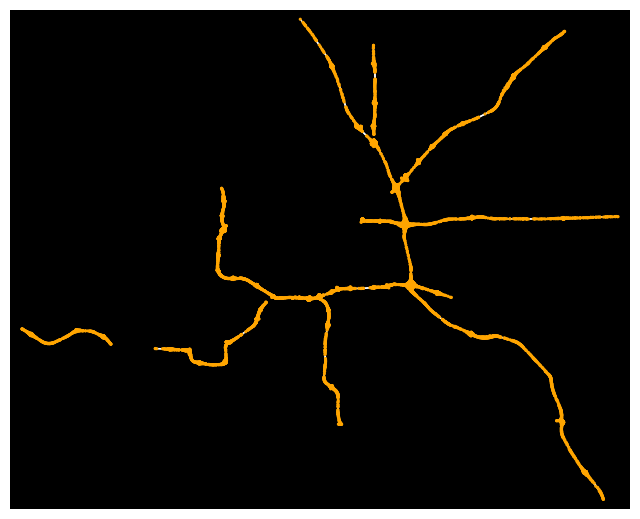

In [2]:
import osmnx as ox
import networkx as nx

# Define your region of interest
place = "Dane County, WI"

# Custom filter for interstate highways only
motorway_filter = '["highway"~"motorway|motorway_link"]'

# Download only interstate highways
G = ox.graph_from_place(
    place,
    custom_filter=motorway_filter,
    simplify=False,   # keep raw geometry, avoids snapping issues
    retain_all=True   # keep disconnected components
)

# Plot
fig, ax = ox.plot_graph(
    G,
    bgcolor="black",
    node_color="orange",
    node_size=5,
    edge_color="white",
    edge_linewidth=1
)


In [3]:
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

1993763541.1266599

In [4]:
# show some basic stats about the network
# documentation: https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.stats
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 9194,
 'm': 9314,
 'k_avg': 2.026103980857081,
 'edge_length_total': 546123.629504609,
 'edge_length_avg': 58.634703618703995,
 'streets_per_node_avg': 2.0219708505547094,
 'streets_per_node_counts': {0: 0, 1: 229, 2: 8543, 3: 413, 4: 9},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.02490754840113117,
  2: 0.9291929519251686,
  3: 0.04492060039155971,
  4: 0.0009788992821405265},
 'intersection_count': 8965,
 'street_length_total': 545965.18918592,
 'street_segment_count': 9291,
 'street_length_avg': 58.76280154837155,
 'circuity_avg': 0.9989958407151,
 'self_loop_proportion': 0.0,
 'clean_intersection_count': 3438,
 'node_density_km': 4.611379338797891,
 'intersection_density_km': 4.496521184720807,
 'edge_density_km': 273.9159475230442,
 'street_density_km': 273.83647956437176,
 'clean_intersection_density_km': 1.72437700313108}

degree_sequence:  [(13754413815, 2), (13736965960, 2), (13731446874, 2), (13731445617, 2), (13729049565, 2), (13712699300, 2), (13429337108, 2), (13427992677, 2), (13427992673, 2), (13427992647, 2), (13427992646, 2), (13427992645, 2), (13427992644, 2), (13427992632, 2), (13427992631, 2), (13427992629, 2), (13427992628, 2), (13410109885, 2), (13410109884, 2), (13410109883, 3), (13410109882, 2), (13410109879, 2), (13410109876, 2), (13410109875, 2), (13410109860, 2), (13410109859, 2), (13410109857, 2), (13410109852, 2), (13410109848, 2), (13410109847, 2), (13410109846, 2), (13410109833, 2), (13410109832, 2), (13410109831, 2), (13410109830, 2), (13410109829, 2), (13410109828, 2), (13410109827, 2), (13410109826, 2), (13410109825, 2), (13410109822, 2), (13408022798, 2), (13408022797, 2), (13408022796, 2), (13408022795, 2), (13408022794, 2), (13408022793, 2), (13408022792, 2), (13408022791, 2), (13408022790, 2), (13408022789, 2), (13408022788, 2), (13408022787, 2), (13408022786, 2), (13408022

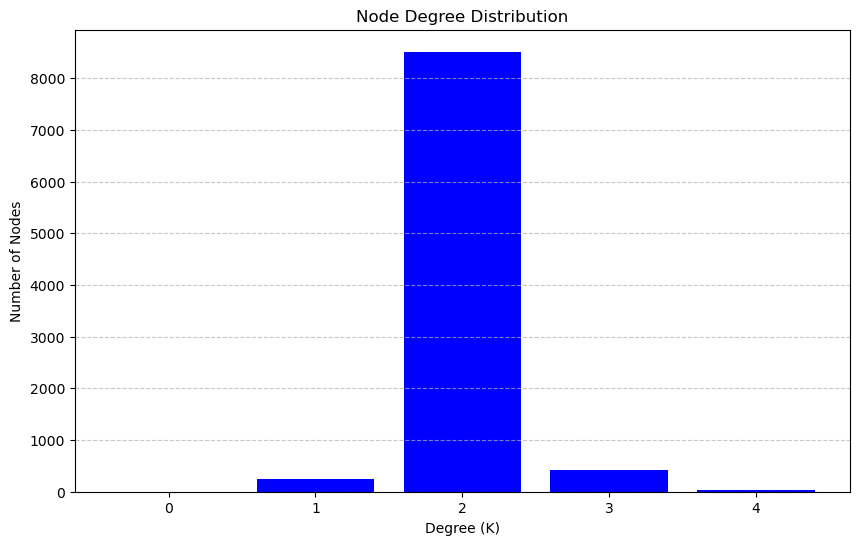

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

# Get node degrees from the graph G (already loaded in cell F9aCnDYw8y4l)
# For a MultiDiGraph, G.degree() returns (in_degree + out_degree) by default.
# If a simple undirected degree distribution is preferred, one could convert G to undirected first:
# G_undirected = G.to_undirected()
# degrees = [d for n, d in G_undirected.degree()]

# Compute the degree distribution and the histogram
degree_sequence = sorted([d for d in G.degree()], reverse=True)  # degree sequence
print("degree_sequence: ", degree_sequence)

degree_counts = nx.degree_histogram(G)
print("degree_counts: ", degree_counts)

# The degree_histogram function returns a list where the index is the degree
# and the value is the count of nodes with that degree.

# Create a list of degrees (x-axis for the plot)
degrees_x = range(len(degree_counts))

# Plot the degree distribution
plt.figure(figsize=(10, 6))
plt.bar(degrees_x, degree_counts, width=0.8, color='b')
plt.title("Node Degree Distribution")
plt.xlabel("Degree (K)")
plt.ylabel("Number of Nodes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

                  y          x            highway   ref  street_count  \
osmid                                                                   
29981753  43.055846 -89.277445  motorway_junction  142A             3   
29981754  43.057651 -89.277338                NaN   NaN             2   
29981755  43.060656 -89.277209                NaN   NaN             2   
29981756  43.063423 -89.277272                NaN   NaN             2   
29981757  43.063847 -89.277349                NaN   NaN             2   

                            geometry  
osmid                                 
29981753  POINT (-89.27745 43.05585)  
29981754  POINT (-89.27734 43.05765)  
29981755  POINT (-89.27721 43.06066)  
29981756  POINT (-89.27727 43.06342)  
29981757  POINT (-89.27735 43.06385)  
                              osmid        highway lanes  oneway  reversed  \
u        v           key                                                     
29981753 9168455951  0      6587457  motorway_link     2   

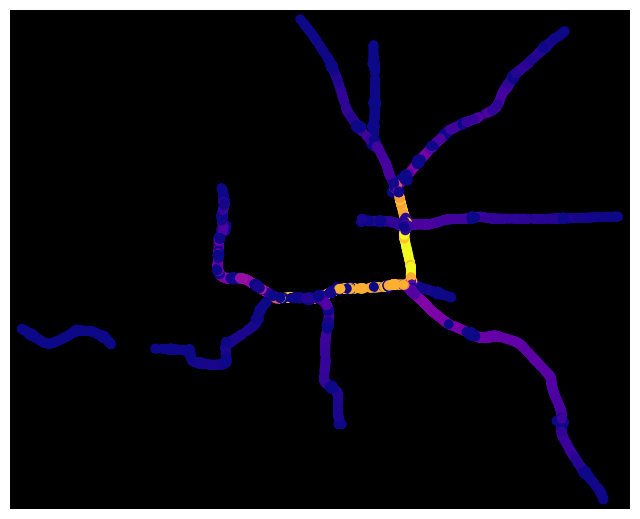

In [6]:
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True

# download street network data from OSM and construct a MultiDiGraph model
#G = ox.graph.graph_from_point((43.075573, -89.415233), dist=1000, network_type="drive")

# impute edge (driving) speeds and calculate edge travel times
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

# you can convert MultiDiGraph to/from GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
G = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)

print(gdf_nodes.head())
print(gdf_edges.head())

# convert MultiDiGraph to DiGraph to use nx.betweenness_centrality function
# choose between parallel edges by minimizing travel_time attribute value
D = ox.convert.to_digraph(G, weight="travel_time")

# calculate node betweenness centrality, weighted by travel time
bc = nx.betweenness_centrality(D, weight="travel_time", normalized=True)
nx.set_node_attributes(G, values=bc, name="bc")

# plot the graph, coloring nodes by betweenness centrality
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot.plot_graph(
    G, bgcolor="k", node_color=nc, node_size=50, edge_linewidth=2, edge_color="#333333"
)

# save graph as a geopackage or graphml file
ox.io.save_graph_geopackage(G, filepath="./graph.gpkg")
ox.io.save_graphml(G, filepath="./graph.graphml")

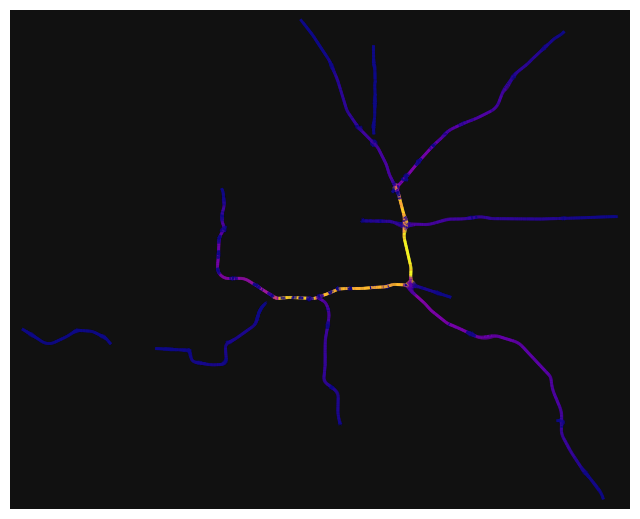

In [7]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.betweenness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, 'edge_centrality')
# color edges in original graph with closeness centralities from line graph
#https://matplotlib.org/stable/users/explain/colors/colormaps.html
ec = ox.plot.get_edge_colors_by_attr(G, 'edge_centrality', cmap='plasma')
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

In [9]:
#Export GeoJSONs to files
gdf_edges.to_file("graph_edges.geojson", driver="GeoJSON")
gdf_nodes.to_file("graph_nodes.geojson", driver="GeoJSON")

In [11]:

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)


In [12]:
gdf_edges.to_file("edges_with_centrality.geojson", driver="GeoJSON")


In [13]:
gdf_nodes.to_file("nodes.geojson", driver="GeoJSON")


In [14]:
import geopandas as gpd

#Load in files containing VMT, Proximity to EV chargers, and betweenness centrality
g1 = gpd.read_file("/Users/sleibowitz/Downloads/edges_with_centrality.geojson")          # Dane County OSMnx edges
g2 = gpd.read_file("/Users/sleibowitz/Downloads/interstates_with_charger_info.geojson")  # National dataset


In [15]:
#Reproject g2
g2 = g2.to_crs(epsg=4326)


In [16]:
#Condense g2 to only include interstate highways in Dane County

import osmnx as ox

dane = ox.geocode_to_gdf("Dane County, Wisconsin")


In [17]:
dane_union = dane.union_all()
g2_dane = g2[g2.intersects(dane_union)]



In [18]:
#Simplify geometry
g1.loc[:, "geom_simple"] = g1.geometry.simplify(0.00001)
g2_dane = g2_dane.copy()  
g2_dane.loc[:, "geom_simple"] = g2_dane.geometry.simplify(0.00001)


In [19]:
#Reproject both datasets to a projected CRS
g1_proj = g1.to_crs(3071)
g2_dane_proj = g2_dane.to_crs(3071)


In [20]:

g1_proj["geom_simple"] = g1_proj.geometry.simplify(5)        #(5 meters)
g2_dane_proj["geom_simple"] = g2_dane_proj.geometry.simplify(5)

#Merge datasets
merged_proj = gpd.sjoin_nearest(
    g1_proj.set_geometry("geom_simple"),
    g2_dane_proj.set_geometry("geom_simple"),
    how="left",
    distance_col="match_distance"
)


In [21]:
merged = merged_proj.to_crs(4326)


In [36]:
#Ensure there is one correct geometry field
merged = merged.drop(columns=["geom_simple"], errors="ignore")


In [37]:
[col for col in merged.columns if merged[col].dtype == "geometry"]


['geometry_right']

In [38]:
merged.head()


,u,v,key,osmid,highway,lanes,oneway,reversed,length,speed_kph,...,:id,aadt,sectionlength,vmt,index_charger,dist_to_charger,charger_count_within_50_miles,dist_charger_miles,geometry_right,match_distance
0,29981753,9168455951,0,6587457,motorway_link,2,True,False,415.991562,89.53227,...,row-tke3~z2ec.rwej,106826.0,0.12,12819.119999999999,585,9516.876784,52.0,5.913513,"LINESTRING (578841.958 287275.081, 578836.266 ...",0.273606
1,29981753,12812265914,0,992333826,motorway,3,True,False,283.026828,112.65380,...,row-tke3~z2ec.rwej,106826.0,0.12,12819.119999999999,585,9516.876784,52.0,5.913513,"LINESTRING (578841.958 287275.081, 578836.266 ...",0.000000
2,9168455951,9168455950,0,992333828,motorway_link,2,True,False,52.582969,89.53227,...,row-zb2b_miyt_bggb,106826.0,0.02,2136.52,585,9934.305862,52.0,6.172891,"LINESTRING (578831.688 286856.052, 578831.669 ...",11.553258
3,12812265914,448790648,0,1396139174,motorway,3,True,False,138.181814,112.65380,...,row-zb2b_miyt_bggb,106826.0,0.02,2136.52,585,9934.305862,52.0,6.172891,"LINESTRING (578831.688 286856.052, 578831.669 ...",1.497747
4,29981754,29981753,0,23810712,motorway,5,True,False,200.950861,112.65380,...,row-vnha-i4j4_r35c,106826.0,0.46,49139.96,585,8778.930619,52.0,5.454975,"LINESTRING (578856.141 288016.16, 578841.958 2...",0.000000


In [39]:
merged = merged.set_geometry("geometry_right")


In [40]:
for col in merged.columns:
    if merged[col].dtype == "geometry" and col != "geometry_right":
        merged = merged.drop(columns=[col])


In [41]:
merged.to_file("dane_interstates_merged.geojson", driver="GeoJSON")


In [42]:
import geopandas as gpd
import pandas as pd

merged_final = gpd.read_file("dane_interstates_merged.geojson")


In [43]:
merged_final.columns

Index(['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'oneway', 'reversed',
       'length', 'speed_kph', 'travel_time', 'edge_centrality', 'maxspeed',
       'ref', 'bridge', 'name', 'access', 'junction', 'index_right', ':id',
       'aadt', 'sectionlength', 'vmt', 'index_charger', 'dist_to_charger',
       'charger_count_within_50_miles', 'dist_charger_miles', 'match_distance',
       'geometry'],
      dtype='object')

In [44]:
merged_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 13718 entries, 0 to 13717
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   u                              13718 non-null  int64   
 1   v                              13718 non-null  int64   
 2   key                            13718 non-null  int32   
 3   osmid                          13718 non-null  int32   
 4   highway                        13718 non-null  object  
 5   lanes                          12467 non-null  object  
 6   oneway                         13718 non-null  bool    
 7   reversed                       13718 non-null  bool    
 8   length                         13718 non-null  float64 
 9   speed_kph                      13718 non-null  float64 
 10  travel_time                    13718 non-null  float64 
 11  edge_centrality                13718 non-null  float64 
 12  maxspeed                

In [45]:
merged_final.geom_type.value_counts()


LineString    13718
Name: count, dtype: int64

In [46]:
#Change vmt to type float64
merged_final["vmt"] = pd.to_numeric(merged_final["vmt"], errors="coerce")


In [47]:
merged_final.dtypes

u                                   int64
v                                   int64
key                                 int32
osmid                               int32
highway                            object
lanes                              object
oneway                               bool
reversed                             bool
length                            float64
speed_kph                         float64
travel_time                       float64
edge_centrality                   float64
maxspeed                           object
ref                                object
bridge                             object
name                               object
access                             object
junction                           object
index_right                         int32
:id                                object
aadt                               object
sectionlength                      object
vmt                               float64
index_charger                     

In [48]:
#Calculate final combined metric for new EV charging location proposal
merged_final["combined_metric"]=(
    merged_final["edge_centrality"] *
    merged_final["vmt"] *
    merged_final["dist_charger_miles"]
)

In [49]:
merged_final["combined_metric"].describe()

count    13718.000000
mean       427.714510
std       1410.819295
min          0.000000
25%          2.244295
50%         21.702529
75%        177.547748
max      17897.020477
Name: combined_metric, dtype: float64

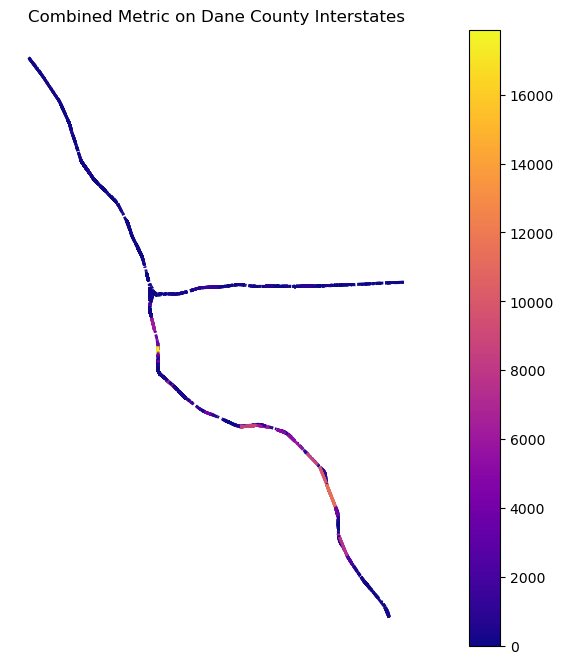

In [62]:
#plot combined_metric
import matplotlib.pyplot as plt

merged_final.plot(
    column="combined_metric",
    cmap="plasma",
    linewidth=2,
    legend=True,
    figsize=(12, 8)
)

plt.title("Combined Metric on Dane County Interstates")
plt.axis("off")
plt.show()


In [63]:
pip install contextily


Note: you may need to restart the kernel to use updated packages.


In [64]:
#Plot logarithm of combined_metric for more intuitive results
import geopandas as gpd
import contextily as ctx

g = merged_final.to_crs(3857)

import numpy as np

g["combined_log"] = np.log1p(g["combined_metric"])

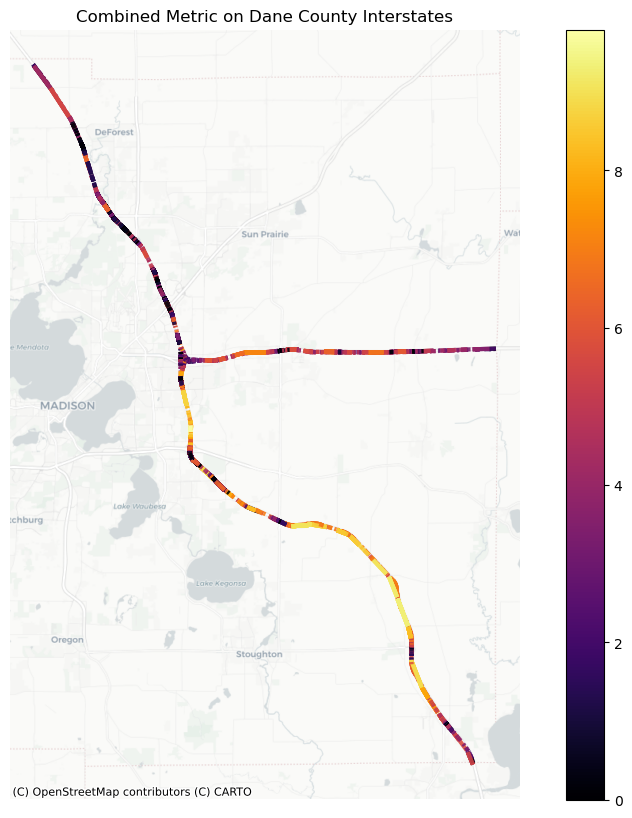

In [65]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

g.plot(
    ax=ax,
    column="combined_log",
    cmap="inferno",
    linewidth=3,
    legend=True,
    alpha=0.9
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,   # clean light basemap
    zoom=11
)

ax.set_axis_off()
plt.title("Combined Metric on Dane County Interstates")
plt.show()


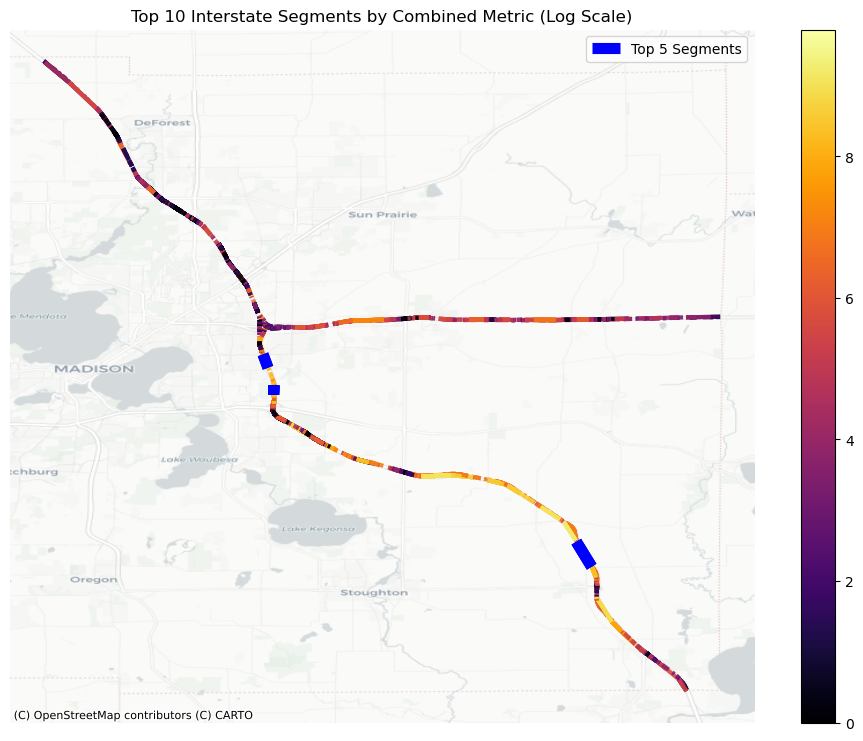

In [99]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Step 1: Reproject
g = merged_final.to_crs(3857)

# Step 2: Compute log metric
g["combined_log"] = np.log1p(g["combined_metric"])

# Step 3: Extract top 5 (and reproject them too)
top10 = merged_final.sort_values("combined_metric", ascending=False).head(10)
top10 = top10.to_crs(3857)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(12, 9))

g.plot(
    ax=ax,
    column="combined_log",
    cmap="inferno",
    linewidth=3,
    legend=True,
    alpha=0.9,
    aspect=None
)

top10.plot(
    ax=ax,
    color="blue",
    linewidth=8,
    alpha=1.0,
    label="Top 5 Segments",
    aspect=None
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

ax.set_axis_off()
plt.title("Top 10 Interstate Segments by Combined Metric (Log Scale)")
plt.legend()
plt.show()


In [100]:
#to see where these linestrings are in google maps:

#convert to lat/lon
start_points_3857 = top10.geometry.apply(lambda geom: geom.coords[0])




In [101]:
from shapely.geometry import Point

start_points_3857 = start_points_3857.apply(lambda xy: Point(xy))



In [102]:
start_points_ll = gpd.GeoSeries(start_points_3857, crs=3857).to_crs(4326)


In [103]:
coords = [(pt.y, pt.x) for pt in start_points_ll]
coords


[(43.08439341124249, -89.28373074067203),
 (43.08439341124249, -89.28373074067203),
 (43.0625738003925, -89.27718648362203),
 (43.0625738003925, -89.27718648362203),
 (43.0625738003925, -89.27718648362203),
 (43.0625738003925, -89.27718648362203),
 (43.0625738003925, -89.27718648362203),
 (42.952138712862514, -89.09749956143202),
 (42.952138712862514, -89.09749956143202),
 (42.952138712862514, -89.09749956143202)]

In [104]:
urls = [
    f"https://www.google.com/maps?q={lat},{lon}"
    for lat, lon in coords
]
urls



['https://www.google.com/maps?q=43.08439341124249,-89.28373074067203',
 'https://www.google.com/maps?q=43.08439341124249,-89.28373074067203',
 'https://www.google.com/maps?q=43.0625738003925,-89.27718648362203',
 'https://www.google.com/maps?q=43.0625738003925,-89.27718648362203',
 'https://www.google.com/maps?q=43.0625738003925,-89.27718648362203',
 'https://www.google.com/maps?q=43.0625738003925,-89.27718648362203',
 'https://www.google.com/maps?q=43.0625738003925,-89.27718648362203',
 'https://www.google.com/maps?q=42.952138712862514,-89.09749956143202',
 'https://www.google.com/maps?q=42.952138712862514,-89.09749956143202',
 'https://www.google.com/maps?q=42.952138712862514,-89.09749956143202']